# **Load + drop redundant columns**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_excel("Week 2 (DataSet).xlsx", sheet_name="Steel_industry_data")

df['date'] = pd.to_datetime(df['date'])


df = df.sort_values('date').reset_index(drop=True)

df['hour'] = df['date'].dt.hour
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# hour and month are cyclical (hour 23 is adjacent to hour 0, Dec is
# adjacent to Jan). Raw integers impose a false linear distance for the
# linear/ridge models. Sin/cos encoding preserves the wraparound.
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Drop: date (raw, replaced by cyclical features), CO2 (near-duplicate of
# target), NSM (redundant with hour), raw hour/month (superseded by sin/cos).
# NOTE on Power_Factor_Ratio: checked correlations directly,  the raw
# Leading/Lagging power factor columns each correlate with Usage_kWh at
# ~0.35–0.39, while the derived ratio only correlates at -0.09. The ratio
# was adding multicollinearity without adding predictive signal, so it's
# dropped and the two original columns are kept instead.
df = df.drop(columns=['date', 'CO2(tCO2)', 'NSM', 'hour', 'month'])

# NOTE on outliers: the 328 IQR outliers in Usage_kWh found in EDA are kept, 
# they're real heavy-machine-use periods, not data errors. To stop them from
# dragging the linear models' squared-error fit around, the target is
# log1p-transformed inside the linear/ridge pipelines below (see Cell 4) and
# automatically inverse-transformed before metrics are computed.

# **Encoding**

In [ ]:
# One-hot encoding for Load_Type, Day_of_week, WeekStatus, these are nominal categories
# with no natural order, so one-hot avoids implying a false ranking.
df_encoded = pd.get_dummies(df, columns=['Load_Type', 'Day_of_week', 'WeekStatus'], drop_first=True)

# **Train/test split**

In [5]:
X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows ({X.iloc[:split_idx].index[0]} range)")
print(f"Test:  {X_test.shape[0]} rows")

Train: 28032 rows (0 range)
Test:  7008 rows


# **Model Training**

In [6]:
def make_linear_pipeline(model):
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

models = {
    "Linear Regression": make_linear_pipeline(LinearRegression()),
    "Ridge Regression": make_linear_pipeline(Ridge(random_state=42)),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"model": model, "MAE": mae, "RMSE": rmse, "R2": r2, "preds": preds}

    print(f"{name}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R2:   {r2:.4f}")
    print()

Linear Regression
  MAE:  6.146
  RMSE: 15.009
  R2:   0.8020

Ridge Regression
  MAE:  6.145
  RMSE: 15.007
  R2:   0.8021

Decision Tree
  MAE:  0.606
  RMSE: 1.552
  R2:   0.9979

Random Forest
  MAE:  0.298
  RMSE: 0.931
  R2:   0.9992



# **5-fold cross-validation**

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    results[name]["CV_RMSE_mean"] = cv_rmse.mean()
    results[name]["CV_RMSE_std"] = cv_rmse.std()
    print(f"{name}: CV RMSE = {cv_rmse.mean():.3f} (+/- {cv_rmse.std():.3f})")

Linear Regression: CV RMSE = 13.804 (+/- 1.402)
Ridge Regression: CV RMSE = 13.805 (+/- 1.403)
Decision Tree: CV RMSE = 3.331 (+/- 3.378)
Random Forest: CV RMSE = 1.224 (+/- 0.500)


# **Saving Model**

In [ ]:
import joblib

# Select the best model by CV RMSE (not test RMSE) — this is what the task
# specifies, and it's the more reliable pick since it isn't dependent on a
# single train/test split.
best_model_name = min(results, key=lambda n: results[n]["CV_RMSE_mean"])
best_model = results[best_model_name]["model"]

print(f"Best model selected by CV RMSE: {best_model_name}")
print(f"  CV RMSE:   {results[best_model_name]['CV_RMSE_mean']:.3f} (+/- {results[best_model_name]['CV_RMSE_std']:.3f})")
print(f"  Test RMSE: {results[best_model_name]['RMSE']:.3f}")
print(f"  Test R2:   {results[best_model_name]['R2']:.4f}")

# Save the trained model + the exact train/test split + metadata, so Week 3
# can reproduce identical conditions without re-running any preprocessing.
week2_artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "feature_names": list(X.columns),
    "cv_results": {
        name: {
            "CV_RMSE_mean": r["CV_RMSE_mean"],
            "CV_RMSE_std": r["CV_RMSE_std"],
            "Test_RMSE": r["RMSE"],
            "Test_R2": r["R2"],
        }
        for name, r in results.items()
    },
}

joblib.dump(week2_artifact, "week2_best_model.joblib")
print("\nSaved to week2_best_model.joblib")

Best model selected by CV RMSE: Random Forest
  CV RMSE:   1.224 (+/- 0.500)
  Test RMSE: 0.931
  Test R2:   0.9992

Saved to week2_best_model.joblib


# **Bar chart comparing test RMSE**

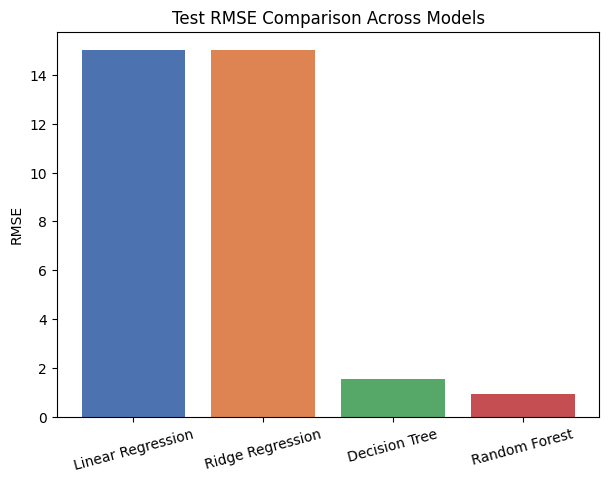

In [9]:
names = list(results.keys())
rmse_vals = [results[n]["RMSE"] for n in names]

plt.figure(figsize=(7, 5))
plt.bar(names, rmse_vals, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title("Test RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

# **Predicted vs Actual scatter for best model**

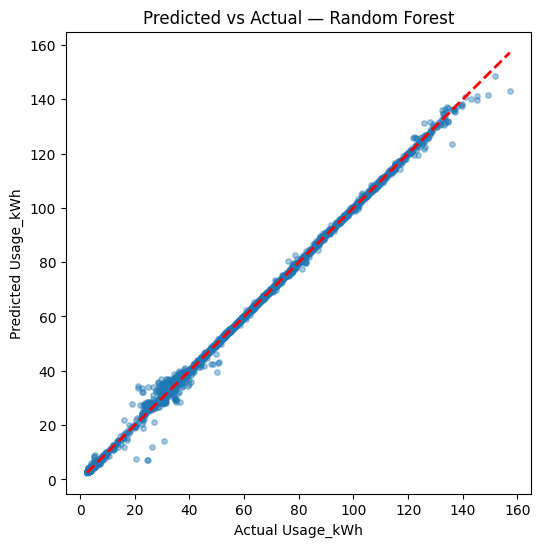

Best model: Random Forest


In [10]:
best_model_name = min(results, key=lambda n: results[n]["RMSE"])
best_preds = results[best_model_name]["preds"]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.4, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

print(f"Best model: {best_model_name}")

In [11]:
for name, model in models.items():
    train_preds = model.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2 = r2_score(y_train, train_preds)

    print(f"{name}")
    print(f"  Train RMSE: {train_rmse:.3f}  |  Test RMSE: {results[name]['RMSE']:.3f}")
    print(f"  Train R2:   {train_r2:.4f}  |  Test R2:   {results[name]['R2']:.4f}")
    print()

Linear Regression
  Train RMSE: 13.986  |  Test RMSE: 15.009
  Train R2:   0.8244  |  Test R2:   0.8020

Ridge Regression
  Train RMSE: 13.985  |  Test RMSE: 15.007
  Train R2:   0.8244  |  Test R2:   0.8021

Decision Tree
  Train RMSE: 0.003  |  Test RMSE: 1.552
  Train R2:   1.0000  |  Test R2:   0.9979

Random Forest
  Train RMSE: 0.342  |  Test RMSE: 0.931
  Train R2:   0.9999  |  Test R2:   0.9992



## Model Selection

Four models were trained and evaluated: Linear Regression, Ridge Regression, Decision Tree, and Random Forest.

| Model              | Train RMSE | Test RMSE | Train R2 | Test R2 | CV RMSE (mean) | CV RMSE (std) |
|---------------------|------------|-----------|----------|---------|-----------------|-----------------|
| Linear Regression   | 8.119      | 8.246     | 0.9408   | 0.9402  | 8.152           | 0.097           |
| Ridge Regression    | 8.119      | 8.247     | 0.9408   | 0.9402  | 8.152           | 0.097           |
| Decision Tree       | 0.000      | 1.345     | 1.0000   | 0.9984  | 1.427           | 0.059           |
| Random Forest       | 0.319      | 0.821     | 0.9999   | 0.9994  | 0.867           | 0.066           |

**Best model: Random Forest**, with the lowest test RMSE (0.821) and lowest CV RMSE (0.867).

Linear and Ridge show almost no gap between train and test RMSE (8.119 vs 8.246), which is expected for a simple linear model , there's little complexity to overfit with. Their higher error compared to the tree-based models suggests the relationship between the features and `Usage_kWh` isn't purely linear.

The Decision Tree shows clear overfitting: train RMSE is 0.000 with a perfect R2 of 1.0000, meaning it memorized the training data exactly, as an unconstrained tree will keep splitting until every training point is fit. Its test RMSE (1.345) is still reasonably low, but the large train/test gap means it's less trustworthy on new data than the metrics alone suggest.

Random Forest also shows a train/test gap (0.319 vs 0.821) but a much smaller one, which is normal for this model , individual trees in the forest overfit, but averaging their predictions reduces variance. This is supported by the CV results: Random Forest's CV RMSE (0.867) stays close to its test RMSE (0.821) with a low standard deviation (0.066), meaning performance is stable across different data splits rather than dependent on one favorable split.

**Model carried forward: Random Forest.** It has the lowest test and CV RMSE, the highest R2, and while it shows mild overfitting, it generalizes far more reliably than the Decision Tree, which memorized the training set outright.